# Data Mining - PL6

Setup and imports.

In [10]:
%pip install gensim nltk scikit-learn matplotlib seaborn transformers datasets torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')
print('Setup complete!')

Note: you may need to restart the kernel to use updated packages.
Setup complete!


## Part 1 - Word Embeddings with Gensim

**1.1 Load Models**

In [11]:
import gensim 
import gensim.downloader as api 
 
print("Modelos disponíveis no Gensim:") 
for model_name in list(api.info()['models'].keys())[:5]:  # Mostrar apenas 5  
    print(f"  - {model_name}") 
 
print("\n" + "="*60) 
print("CARREGANDO MODELOS (pode levar alguns minutos)...") 
print("="*60) 
 
word2vec = api.load('word2vec-google-news-300')
 
print("\n1. Word2Vec carregado!") 
 
glove = api.load('glove-twitter-200')
 
print("2. GloVe carregado!") 
 
fasttext = api.load('fasttext-wiki-news-subwords-300')
 
print("3. FastText carregado!") 
print("Todos os modelos carregados com sucesso!") 

Modelos disponíveis no Gensim:
  - fasttext-wiki-news-subwords-300
  - conceptnet-numberbatch-17-06-300
  - word2vec-ruscorpora-300
  - word2vec-google-news-300
  - glove-wiki-gigaword-50

CARREGANDO MODELOS (pode levar alguns minutos)...

1. Word2Vec carregado!
2. GloVe carregado!
3. FastText carregado!
Todos os modelos carregados com sucesso!


In [12]:
word_pairs = [
    ('carro', 'automóvel'),
    ('feliz', 'contente'),
    ('gato', 'cão'),
    ('rei', 'rainha'),
    ('computador', 'teclado'),
    ('amor', 'ódio'),
    ('rápido', 'veloz'),
    ('bom', 'mau')
]

results = {
    'word1': [], 'word2': [],
    'similarity_word2vec': [], 'similarity_glove': [], 'similarity_fasttext': []
}

def get_similarity(model, word1, word2, model_name):
    """ 
    Retorna a similaridade entre word1 e word2 usando o modelo. 
    Se alguma palavra não for encontrada, retorna NaN e imprime aviso. 
""" 
    try:
        similarity = model.similarity(word1, word2)
        return similarity 
    except KeyError:
        return np.nan

for word1, word2 in word_pairs:
    results['word1'].append(word1)
    results['word2'].append(word2)
    results['similarity_word2vec'].append(get_similarity(word2vec, word1, word2, 'word2vec'))
    results['similarity_glove'].append(get_similarity(glove, word1, word2, 'glove'))
    results['similarity_fasttext'].append(get_similarity(fasttext, word1, word2, 'fasttext'))

df_similarities = pd.DataFrame(results)
print(df_similarities)

        word1      word2  similarity_word2vec  similarity_glove  \
0       carro  automóvel                  NaN          0.236243   
1       feliz   contente                  NaN          0.418507   
2        gato        cão                  NaN          0.425261   
3         rei     rainha                  NaN          0.508517   
4  computador    teclado                  NaN          0.604448   
5        amor       ódio                  NaN          0.442752   
6      rápido      veloz                  NaN          0.325680   
7         bom        mau             0.452041          0.378306   

   similarity_fasttext  
0                  NaN  
1             0.494629  
2                  NaN  
3                  NaN  
4             0.620778  
5                  NaN  
6             0.586133  
7             0.549158  


**1.2**

* **1.2.5:** D) rápido-veloz
* **1.2.6:** B) Porque palavras opostas aparecem em contextos semelhantes

**1.3 Visualização de Similaridades**

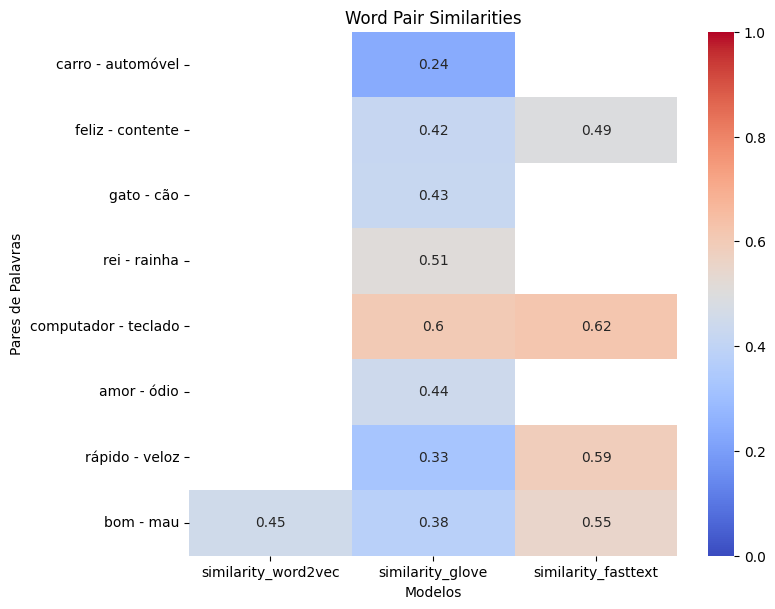

In [13]:
plt.figure(figsize=(8, 6))
sim_matrix = df_similarities[['similarity_word2vec', 'similarity_glove', 'similarity_fasttext']]

sns.heatmap(
    sim_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=0, 
    vmax=1,
    yticklabels=df_similarities['word1'] + ' - ' + df_similarities['word2']
)

plt.title('Word Pair Similarities')
plt.tight_layout()
plt.ylabel('Pares de Palavras') 
plt.xlabel('Modelos') 
plt.show()

In [14]:
analogies = [
    ('rei', 'homem', 'mulher'),      # rei - homem + mulher = ? 
    ('paris', 'frança', 'alemanha'),  # paris - frança + alemanha = ? 
    ('correr', 'correu', 'comeu'),    # correr - correu + comeu = ? (verbos)
]

print("\n" + "="*60) 
print("TESTAR ANALOGIAS") 
print("="*60)

for model_name, model in [('Word2Vec', word2vec), ('Glove', glove), ('FastText', fasttext)]:
    print(f"\n {model_name}:")
    for king, man, woman in analogies: # Complete o unpacking das variáveis
        positive = [woman, king]
        negative = [man]
        try:
            result = model.most_similar(positive=positive, negative=negative)
            print(f"\n  {king} - {man} + {woman} ?")
            for word, score in result:
                print(f" - {word}: {score:.4f}")
        except KeyError as e:
            print(f" Palavra não encontrada: {e}")


TESTAR ANALOGIAS

 Word2Vec:
 Palavra não encontrada: "Key 'mulher' not present in vocabulary"
 Palavra não encontrada: "Key 'alemanha' not present in vocabulary"
 Palavra não encontrada: "Key 'comeu' not present in vocabulary"

 Glove:

  rei - homem + mulher ?
 - rainha: 0.5743
 - vivi: 0.4985
 - tia: 0.4846
 - reis: 0.4790
 - diva: 0.4576
 - mel: 0.4564
 - linda: 0.4541
 - davi: 0.4422
 - claudia: 0.4415
 - samba: 0.4371

  paris - frança + alemanha ?
 - london: 0.5894
 - berlin: 0.5779
 - france: 0.5676
 - amsterdam: 0.5487
 - germany: 0.5234
 - europe: 0.5231
 - york: 0.5190
 - nyc: 0.5160
 - portugal: 0.5118
 - toronto: 0.5081

  correr - correu + comeu ?
 - comer: 0.6305
 - hora: 0.5255
 - tomar: 0.5175
 - beber: 0.5129
 - parar: 0.5117
 - comida: 0.5044
 - pegar: 0.4977
 - vaca: 0.4846
 - gorda: 0.4835
 - gordo: 0.4819

 FastText:

  rei - homem + mulher ?
 - ente: 0.5816
 - repente: 0.5687
 - achei: 0.5643
 - assa: 0.5620
 - deve: 0.5573
 - duen: 0.5571
 - achi: 0.5548
 - sen

**1.4**

B) Glove

In [15]:
test_words = ['neural', 'transformers', 'chatgpt', 'pós-modernismo']

print("\n" + "="*60) 
print("TESTANDO PALAVRAS FORA DO VOCABULÁRIO (OOV)") 
print("="*60) 
 
 
 
for word in test_words:
    for model_name, model in [('Word2Vec', word2vec), ('Glove', glove), ('FastText', fasttext)]:
        try:
            vector = model[word]
            print(f" {model_name}: encontrada (vetor dimensão {len(vector)})")
            
            similar = model.most_similar(word, topn=3)
            print(f" Palavras similares: {[s[0] for s in similar]}")
        except KeyError:
            print(f" x {model_name}: NÃO encontrada")
            
            if model_name == 'FastText' and hasattr(model, 'get_vector'):
                try:
                    vector = model.get_vector(word)
                    print(f" FastText (subwords) conseguiu gerar vetor!")
                except:
                    pass


TESTANDO PALAVRAS FORA DO VOCABULÁRIO (OOV)
 Word2Vec: encontrada (vetor dimensão 300)
 Palavras similares: ['neuronal', 'neurons', 'neural_circuits']
 Glove: encontrada (vetor dimensão 200)
 Palavras similares: ['pathways', 'adaptive', 'mechanisms']
 FastText: encontrada (vetor dimensão 300)
 Palavras similares: ['neuronal', 'non-neural', 'cortical']
 Word2Vec: encontrada (vetor dimensão 300)
 Palavras similares: ['transformer', 'substations', '##KV']
 Glove: encontrada (vetor dimensão 200)
 Palavras similares: ['transformer', 'avengers', 'terminator']
 FastText: encontrada (vetor dimensão 300)
 Palavras similares: ['transformer', 'inverters', 'autotransformers']
 x Word2Vec: NÃO encontrada
 x Glove: NÃO encontrada
 x FastText: NÃO encontrada
 x Word2Vec: NÃO encontrada
 x Glove: NÃO encontrada
 x FastText: NÃO encontrada


**1.5 OOV Words**

* **1.5.2:** D) Nenhum conseguiu
* **1.5.3:** B) Porque usa subpalavras (n-grams de caracteres)

## Part 2 - BERT and Contextual Embeddings

**2.1 Load BERT**

In [16]:
from transformers import AutoTokenizer, AutoModel
import torch


print("="*60) 
print("CARREGANDO BERT (pode levar alguns minutos)...") 
print("="*60) 

model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

print(f"Modelo '{model_name}' carregado!") 
print(f"Tamanho do vocabulário: {tokenizer.vocab_size}") 
print(f"Dimensão dos embeddings: {model.config.hidden_size}") 

CARREGANDO BERT (pode levar alguns minutos)...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3081.55it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo 'bert-base-multilingual-cased' carregado!
Tamanho do vocabulário: 119547
Dimensão dos embeddings: 768


**2.2 Polysemic Words**

In [17]:
sentences = [ 
    "Fui ao banco depositar dinheiro.",           # banco financeiro 
    "Sentei no banco da praça para descansar.",   # banco (assento) 
    "O banco de dados está corrompido.",          # banco de dados
    "O barco encalhou no banco de areia.",        # banco de areia
] 
 
print("\n" + "="*60) 
print("ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS") 
print("="*60) 

def get_word_embedding(sentence, word, tokenizer, model):
    inputs = tokenizer(sentence, return_tensors="pt") 
    with torch.no_grad():
        outputs = model(**inputs) 
    
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    word_positions = [] 
    for i, token in enumerate(tokens):
        if word in token or (token.startswith("##") and word in token): 
            word_positions.append(i)

    word_embedding = outputs.last_hidden_state[0, word_positions[0]].numpy()
    return word_embedding, tokens 


banco_embeddings = []

# Loop de extração
for i, sentence in enumerate(sentences):
    print(f"\n Frase {i+1}: {sentence}") 

    embedding, tokens = get_word_embedding(sentence, "banco", tokenizer, model) 
    if embedding is not None: 
        banco_embeddings.append(embedding) 
        print(f"  Tokens: {tokens}") 
        print(f"  Embedding shape: {embedding.shape}") 
        print(f"  Primeiros 10 valores: {embedding[:10].round(3)}")


ANÁLISE DA PALAVRA 'BANCO' EM DIFERENTES CONTEXTOS

 Frase 1: Fui ao banco depositar dinheiro.
  Tokens: ['[CLS]', 'Fu', '##i', 'ao', 'banco', 'de', '##posit', '##ar', 'dinheiro', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.309 -0.594  0.681  0.691 -0.144  0.621 -0.102  0.138 -0.025  0.066]

 Frase 2: Sentei no banco da praça para descansar.
  Tokens: ['[CLS]', 'Sent', '##ei', 'no', 'banco', 'da', 'pra', '##ça', 'para', 'des', '##cans', '##ar', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.026 -0.266  0.353  0.313  0.215  0.762 -0.526  0.032 -0.276  0.013]

 Frase 3: O banco de dados está corrompido.
  Tokens: ['[CLS]', 'O', 'banco', 'de', 'dados', 'está', 'cor', '##rom', '##pido', '.', '[SEP]']
  Embedding shape: (768,)
  Primeiros 10 valores: [ 0.369 -0.77   0.118  0.827 -0.05   0.941 -0.122 -0.304 -0.366 -0.833]

 Frase 4: O barco encalhou no banco de areia.
  Tokens: ['[CLS]', 'O', 'barco', 'en', '##cal', '##hou', 'no', 'banco', 'de', 

* **2.2.2:** A) 1 token

**2.3 Compare Embeddings**


MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'


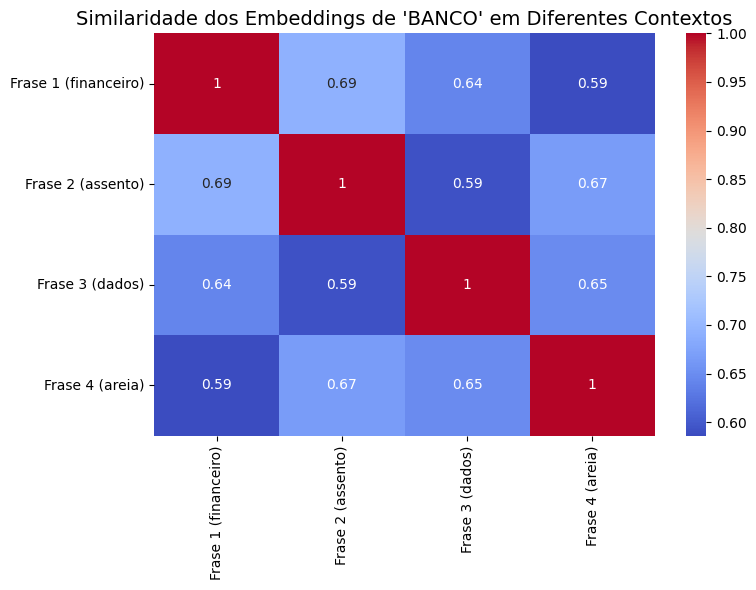


📊 Análise das similaridades:
  Frase 1 (financeiro) ↔ Frase 2 (assento): 0.6915
  Frase 1 (financeiro) ↔ Frase 3 (dados): 0.6423
  Frase 1 (financeiro) ↔ Frase 4 (areia): 0.5860
  Frase 2 (assento) ↔ Frase 3 (dados): 0.5915
  Frase 2 (assento) ↔ Frase 4 (areia): 0.6654
  Frase 3 (dados) ↔ Frase 4 (areia): 0.6482


In [18]:
if len(banco_embeddings) >= 4:
    print("\n" + "="*60)
    print("MATRIZ DE SIMILARIDADE - EMBEDDINGS DE 'BANCO'")
    print("="*60)

    # Calcular matriz de similaridade
    similarity_matrix = np.zeros((4, 4))
    for i in range(4):
        for j in range(4):
            similarity_matrix[i, j] = cosine_similarity([banco_embeddings[i]], [banco_embeddings[j]])[0][0]

    # Criar labels para as frases
    labels = [
        "Frase 1 (financeiro)",
        "Frase 2 (assento)",
        "Frase 3 (dados)",
        "Frase 4 (areia)"
    ]

    # DataFrame para visualização
    df_sim = pd.DataFrame(similarity_matrix, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))

    sns.heatmap(df_sim, annot=True, cmap='coolwarm')
    
    plt.title("Similaridade dos Embeddings de 'BANCO' em Diferentes Contextos", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n📊 Análise das similaridades:")
    for i in range(4):
        for j in range(i+1, 4):
            print(f"  {labels[i]} ↔ {labels[j]}: {similarity_matrix[i,j]:.4f}")

* **2.3.2:** A) Frase 1 (financeiro) e Frase 2 (assento)
* **2.3.3:** C) Frase 1 (financeiro) e Frase 4 (areia)
* **2.3.4:** B) São contextuais, variando conforme o significado